In [20]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [21]:
load_dotenv()

True

In [22]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [ ]:
sub_graph_llm = ChatGroq(model='llama-3.3-70b-versatile')

In [24]:
def translated_text(state: SubState):
    
    prompt = f'''
    Translate the following text into Urdu.
    keep it natural and clear.
    Text:
    {state['input_text']}
    '''.strip()
    translated_text = sub_graph_llm.invoke(prompt)
    return {'translated_text': translated_text}

In [25]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translated_text', translated_text)

subgraph_builder.add_edge(START, 'translated_text')
subgraph_builder.add_edge('translated_text', END)

subgraph = subgraph_builder.compile()

In [26]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [27]:
parent_llm = ChatGroq(model='llama-3.3-70b-versatile')

In [28]:
def generate_answer(state: ParentState):
    prompt = f''' 
    You are a helpful assistant: Generate answer from the following question: {state['question']}
    '''
    response = parent_llm.invoke(prompt)
    
    return{
        'answer_eng': response
    }

In [29]:
def translate_answer(state: ParentState):
    result = subgraph.invoke({'input_text':state['answer_eng']})
    
    return {'answer_urdu': result['translated_text']}

In [30]:
parent_graph = StateGraph(ParentState)

parent_graph.add_node('generate',generate_answer)
parent_graph.add_node('translate',translate_answer)

parent_graph.add_edge(START, 'generate')
parent_graph.add_edge('generate', 'translate')
parent_graph.add_edge('translate', END)

p_graph = parent_graph.compile()

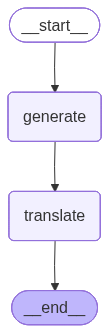

In [31]:
p_graph

In [32]:
result = p_graph.invoke({'question':'what is AI?'})

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [45]:
result['answer_eng']

AIMessage(content="**What is AI?**\n\nArtificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experiences, and interactions, enabling them to improve their performance over time.\n2. **Problem-solving**: AI systems can analyze complex problems, identify patterns, and make decisions or recommendations.\n3. **Reasoning**: AI systems can draw inferences, make connections between concepts, and understand natural language.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n\n**Key Characteristics of AI:**\n\n1. **Intelligence**: AI systems can simulate human intelligence, but they are not conscious or self-aware.\n2. **Autonomy**: AI systems can operate independently, making decisions and taking actions without human intervention.\n3. **Adaptability**: AI systems can adapt to new situa